<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/NMR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import pandas as pd
import os
file_path = r'C:\Users\Fentahun\OneDrive - Ministry of Health - Ethiopia\Desktop\Bewuket\Under5\df_NNM.csv'
df = pd.read_csv(file_path)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Fentahun\\OneDrive - Ministry of Health - Ethiopia\\Desktop\\Bewuket\\Under5\\df_NNM.csv'

In [ ]:
df.head()

,Year,NNM
0,2000,50
1,2001,49
2,2002,49
3,2003,48
4,2004,47


In [ ]:
df.shape

(22, 2)

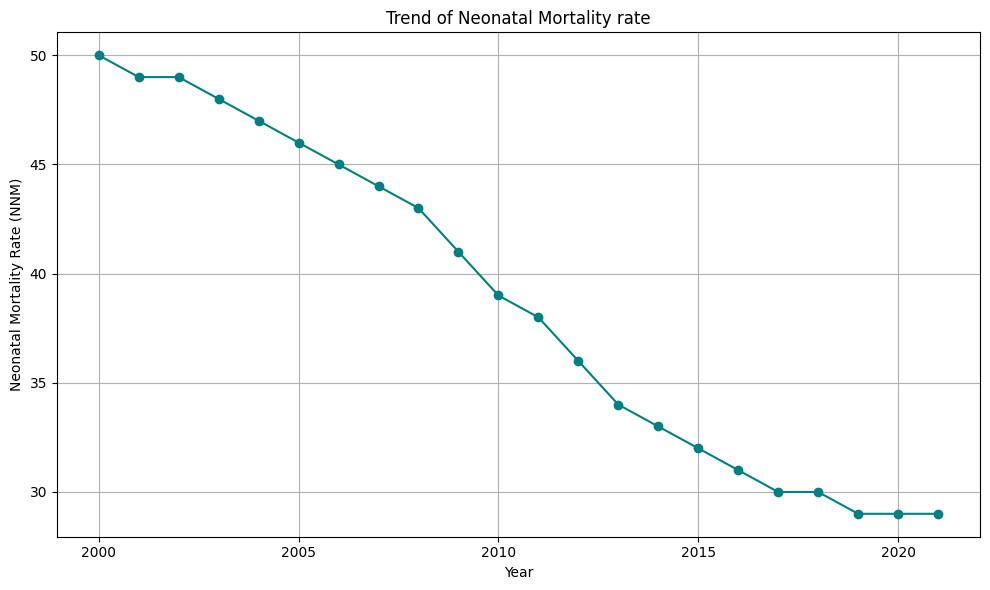

In [ ]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df and has columns 'Year' and 'NNM'
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['NNM'], marker='o', linestyle='-', color='teal')

# Labels and title
plt.xlabel('Year')
plt.ylabel('Neonatal Mortality Rate (NNM)')
plt.title('Trend of Neonatal Mortality rate')
plt.grid(True)
plt.tight_layout()
plt.show()


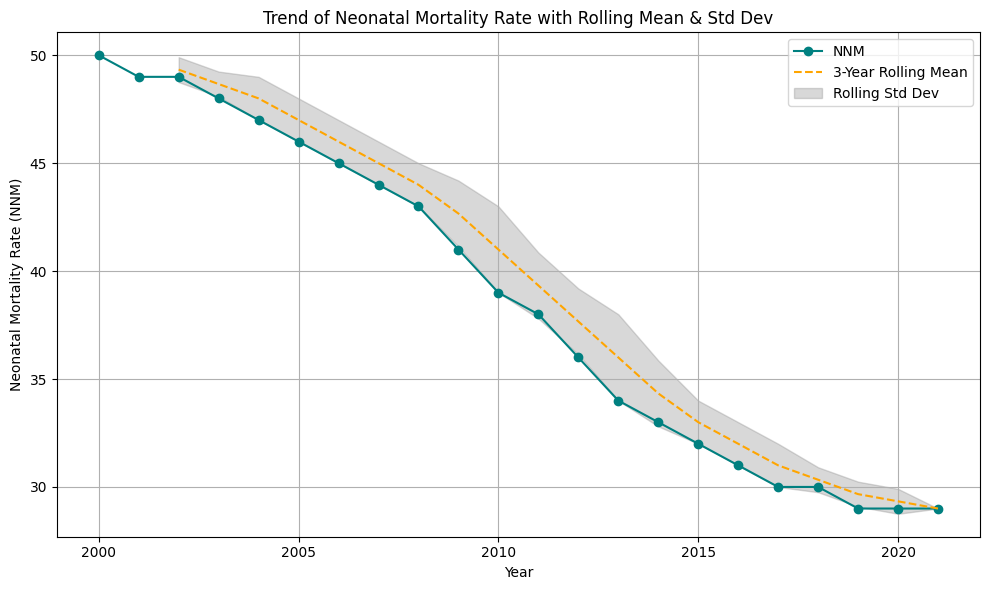

In [ ]:
import matplotlib.pyplot as plt

# Set window size (you can adjust it)
window_size = 3

# Calculate rolling mean and standard deviation
df['rolling_mean'] = df['NNM'].rolling(window=window_size).mean()
df['rolling_std'] = df['NNM'].rolling(window=window_size).std()

# Plotting
plt.figure(figsize=(10, 6))

# Original NNM
plt.plot(df['Year'], df['NNM'], marker='o', linestyle='-', color='teal', label='NNM')

# Rolling mean
plt.plot(df['Year'], df['rolling_mean'], color='orange', linestyle='--', label=f'{window_size}-Year Rolling Mean')

# Rolling standard deviation (optional: shaded area)
plt.fill_between(df['Year'],
                 df['rolling_mean'] - df['rolling_std'],
                 df['rolling_mean'] + df['rolling_std'],
                 color='gray', alpha=0.3, label='Rolling Std Dev')

# Labels and title
plt.xlabel('Year')
plt.ylabel('Neonatal Mortality Rate (NNM)')
plt.title('Trend of Neonatal Mortality Rate with Rolling Mean & Std Dev')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


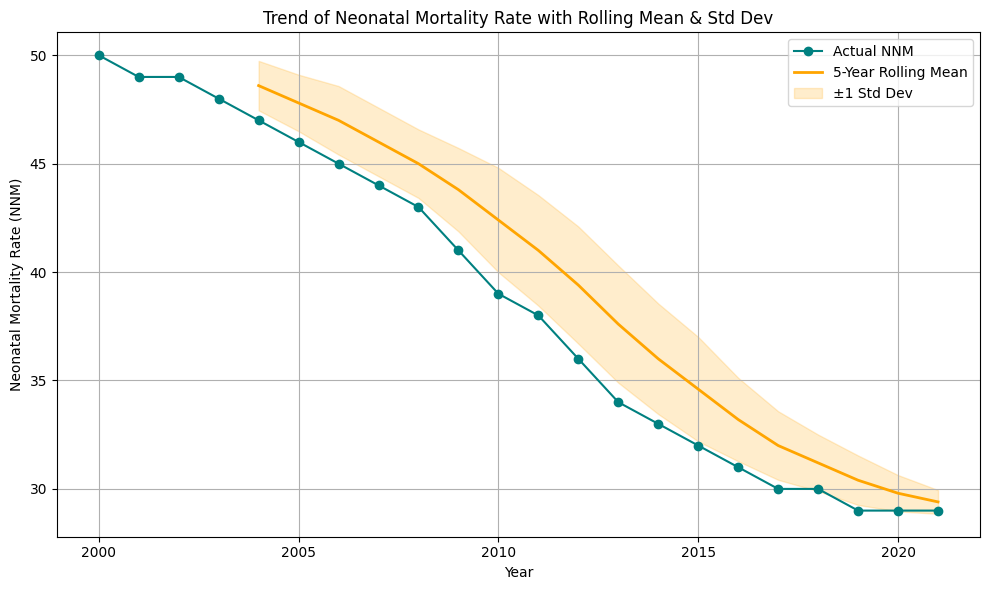

In [ ]:
import matplotlib.pyplot as plt

# Compute rolling statistics
df['NNM_rolling_mean'] = df['NNM'].rolling(window=5).mean()
df['NNM_rolling_std'] = df['NNM'].rolling(window=5).std()

# Plot
plt.figure(figsize=(10, 6))

# Original NNM
plt.plot(df['Year'], df['NNM'], marker='o', linestyle='-', color='teal', label='Actual NNM')

# Rolling Mean
plt.plot(df['Year'], df['NNM_rolling_mean'], color='orange', linewidth=2, label='5-Year Rolling Mean')

# Rolling Std Dev as shaded area
plt.fill_between(df['Year'],
                 df['NNM_rolling_mean'] - df['NNM_rolling_std'],
                 df['NNM_rolling_mean'] + df['NNM_rolling_std'],
                 color='orange', alpha=0.2, label='±1 Std Dev')

# Labels and formatting
plt.xlabel('Year')
plt.ylabel('Neonatal Mortality Rate (NNM)')
plt.title('Trend of Neonatal Mortality Rate with Rolling Mean & Std Dev')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Assign 'Year' column to X and 'NNM' column to y
X = df['Year']
y = df['NNM']


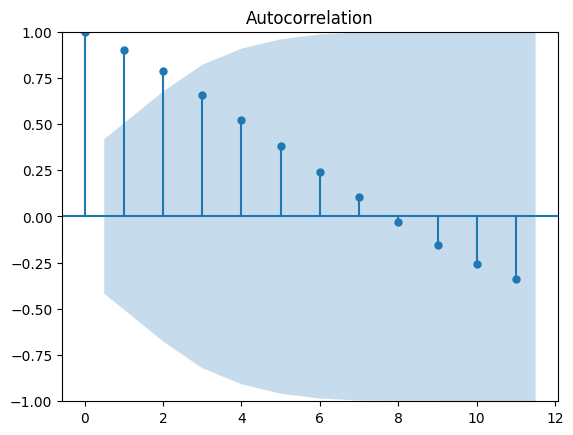

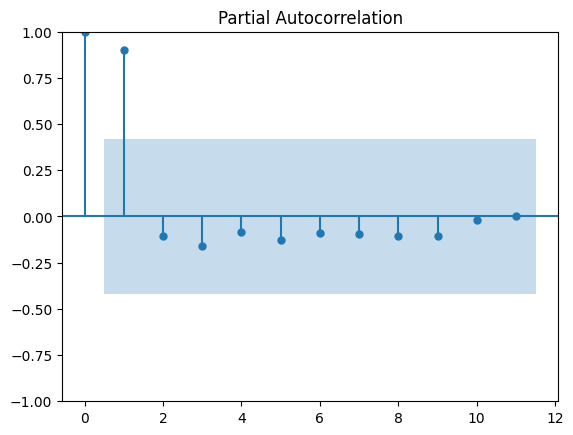

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_original = plot_acf(y)

pacf_original = plot_pacf(y)

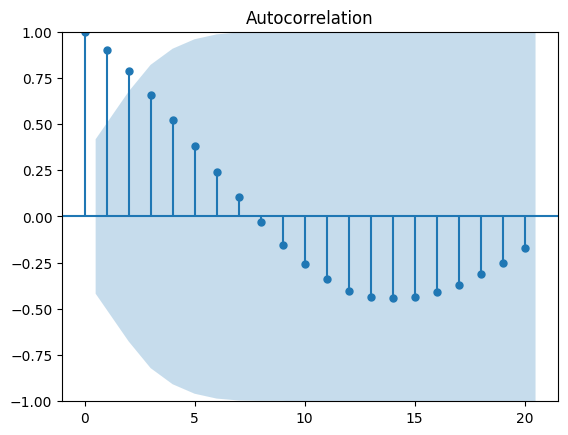

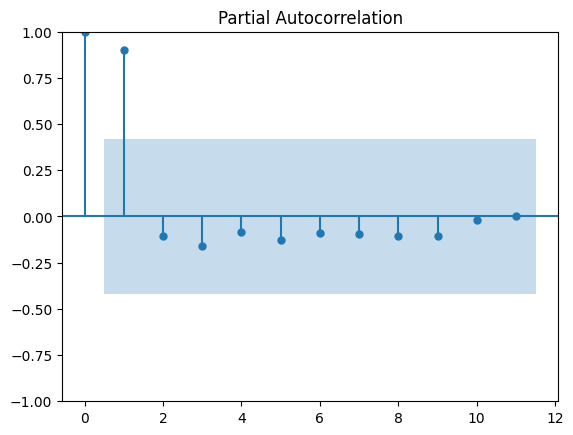

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF plot up to 20 lags
acf_original = plot_acf(y, lags=20)
# Let's assume y has only 20 points
pacf_original = plot_pacf(y)



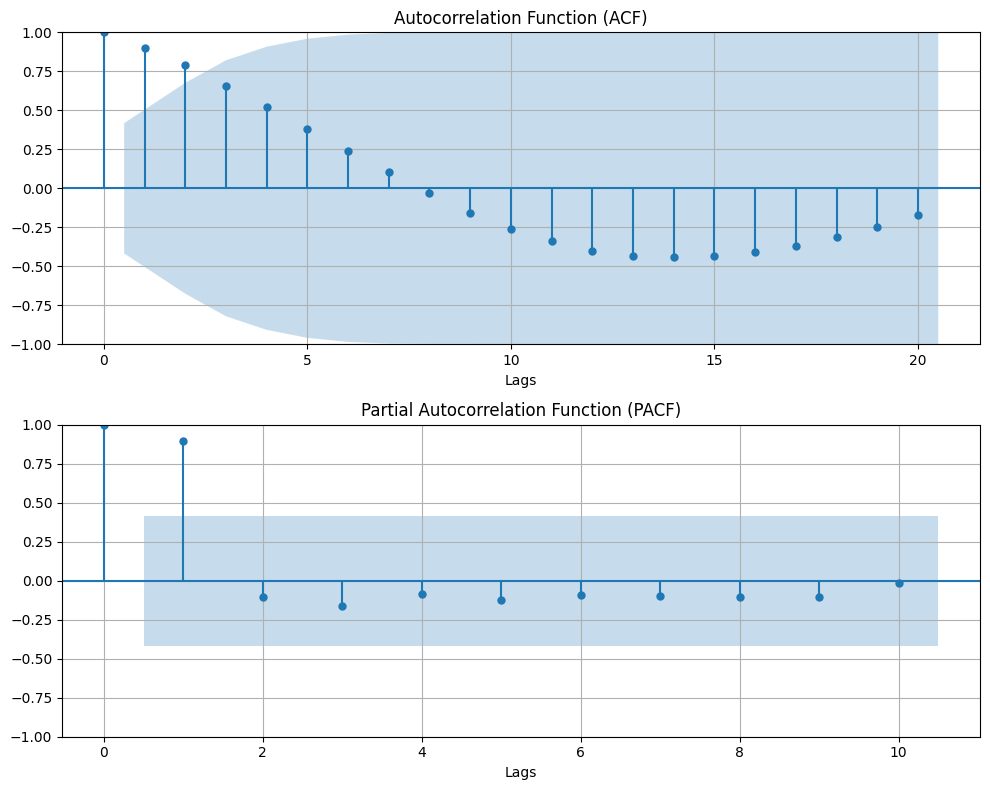

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(10, 8))  # 2 rows, 1 column

# ACF plot (top)
plot_acf(y, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lags')
axes[0].grid(True)

# PACF plot (bottom)
# Ensure lags is less than 50% of series length
max_lags = min(20, len(y) // 2 - 1)
plot_pacf(y, lags=max_lags, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lags')
axes[1].grid(True)

plt.tight_layout()
plt.show()


C:\Users\Fentahun\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\Fentahun\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\Fentahun\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\Fentahun\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Fentahun\anaconda3\Lib\site-packages\keras\src\layers\rnn\rn

📊 Performance Comparison (2022–2030):
                          MAE      RMSE       MAPE      sMAPE
ARIMA                2.171227  2.613577   8.765826   8.226238
LSTM                 2.741200  3.287299  11.060907  10.223195
Multistep LSTM       2.693255  3.234571  10.869921  10.057447
Hybrid (ARIMA+LSTM)  1.722704  2.114585   6.937560   6.606824

📅 Forecasts from 2022–2030:
   Year      ARIMA       LSTM  Multistep LSTM     Hybrid
0  2022  28.825481  28.964174       28.948933  27.704605
1  2023  28.659536  28.886635       28.857826  27.602449
2  2024  28.501743  28.844271       28.805511  27.507952
3  2025  28.351701  28.812033       28.762695  27.422491
4  2026  28.209030  28.806116       28.748932  27.347408
5  2027  28.073368  28.800730       28.737869  27.280491
6  2028  27.944370  28.796673       28.729589  27.221243
7  2029  27.821709  28.794798       28.724516  27.170773
8  2030  27.705073  28.793720       28.721289  27.126936


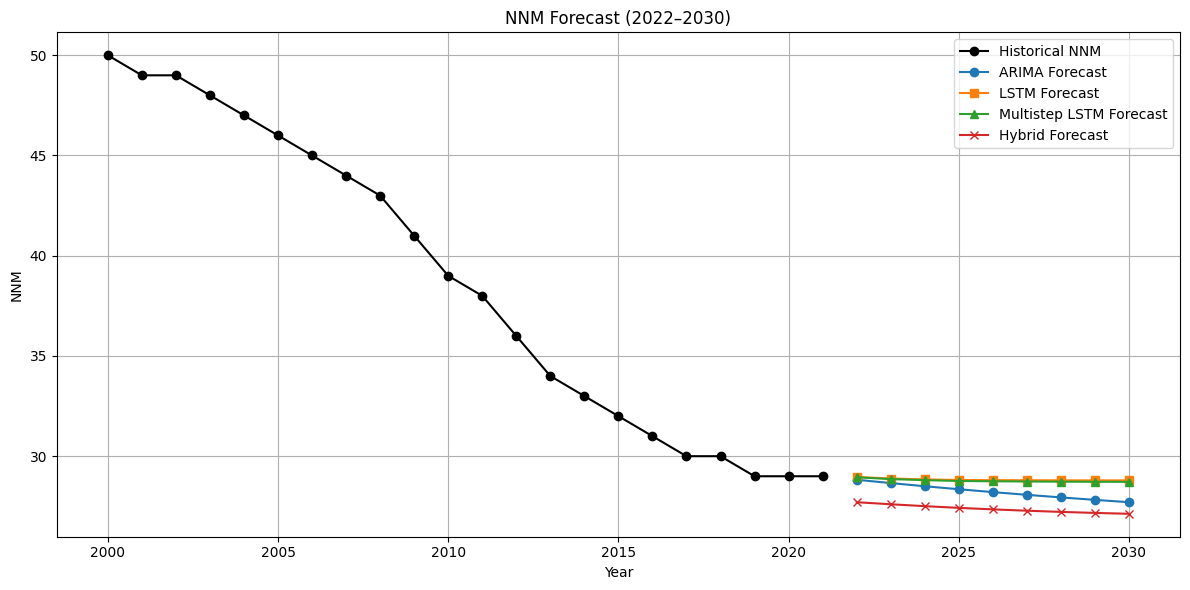

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# ---------- Load & Prepare Data ----------
# Example: df = pd.read_csv('your_data.csv')
X = df['Year']
y = df['NNM']

df_series = pd.Series(y.values, index=pd.to_datetime(X, format='%Y'))

# ---------- Forecast Horizon ----------
future_years = list(range(2022, 2031))
future_index = pd.to_datetime([f"{year}-01-01" for year in future_years])

# ---------- Helper Functions ----------
def smape(actual, predicted):
    return 100 / len(actual) * np.sum(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted)))

def forecast_arima(series):
    model = ARIMA(series, order=(1, 1, 1))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=len(future_years))
    return forecast.values

def prepare_lstm_data(series, n_steps):
    data = series.values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(data)

    X, y = [], []
    for i in range(n_steps, len(scaled)):
        X.append(scaled[i - n_steps:i])
        y.append(scaled[i])

    X, y = np.array(X), np.array(y)
    return X, y, scaler

def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, activation='relu', input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer=Adam(0.01), loss='mse')
    return model

def forecast_lstm(series, n_steps=5, epochs=100):
    X_lstm, y_lstm, scaler = prepare_lstm_data(series, n_steps)
    model = build_lstm_model((n_steps, 1))
    model.fit(X_lstm, y_lstm, epochs=epochs, verbose=0)

    last_input = X_lstm[-1]
    forecast = []

    for _ in range(len(future_years)):
        pred = model.predict(last_input.reshape(1, n_steps, 1), verbose=0)[0][0]
        forecast.append(pred)
        last_input = np.roll(last_input, -1)
        last_input[-1] = pred

    return scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()

def forecast_multistep_lstm(series, n_steps=5, epochs=100):
    return forecast_lstm(series, n_steps, epochs)

def forecast_hybrid(series):
    arima_forecast = forecast_arima(series)
    extension_index = pd.date_range(series.index[-1] + pd.DateOffset(years=1), periods=len(future_years), freq='Y')
    series_extended = pd.concat([series, pd.Series(arima_forecast, index=extension_index)])
    return forecast_lstm(series_extended)

# ---------- Run Forecasts ----------
arima_pred = forecast_arima(df_series)
lstm_pred = forecast_lstm(df_series)
multi_lstm_pred = forecast_multistep_lstm(df_series)
hybrid_pred = forecast_hybrid(df_series)

# ---------- Actual (Fake test set for evaluation) ----------
# Replace with actual data if available
actual = np.linspace(y.values[-1], y.values[-1] * 0.8, len(future_years))

# ---------- Evaluation ----------
def evaluate(actual, predicted):
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
        'MAPE': np.mean(np.abs((actual - predicted) / actual)) * 100,
        'sMAPE': smape(actual, predicted)
    }

metrics = pd.DataFrame({
    'ARIMA': evaluate(actual, arima_pred),
    'LSTM': evaluate(actual, lstm_pred),
    'Multistep LSTM': evaluate(actual, multi_lstm_pred),
    'Hybrid (ARIMA+LSTM)': evaluate(actual, hybrid_pred)
}).T

# ---------- Forecast Results Table ----------
forecast_table = pd.DataFrame({
    'Year': future_years,
    'ARIMA': arima_pred,
    'LSTM': lstm_pred,
    'Multistep LSTM': multi_lstm_pred,
    'Hybrid': hybrid_pred
})

# ---------- Output ----------
print("📊 Performance Comparison (2022–2030):")
print(metrics)

print("\n📅 Forecasts from 2022–2030:")
print(forecast_table)

# ---------- Plot Forecasts ----------
plt.figure(figsize=(12, 6))
plt.plot(df_series.index.year, df_series.values, label='Historical NNM', marker='o', color='black')

plt.plot(future_years, arima_pred, label='ARIMA Forecast', marker='o')
plt.plot(future_years, lstm_pred, label='LSTM Forecast', marker='s')
plt.plot(future_years, multi_lstm_pred, label='Multistep LSTM Forecast', marker='^')
plt.plot(future_years, hybrid_pred, label='Hybrid Forecast', marker='x')

plt.xlabel("Year")
plt.ylabel("NNM")
plt.title("NNM Forecast (2022–2030)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



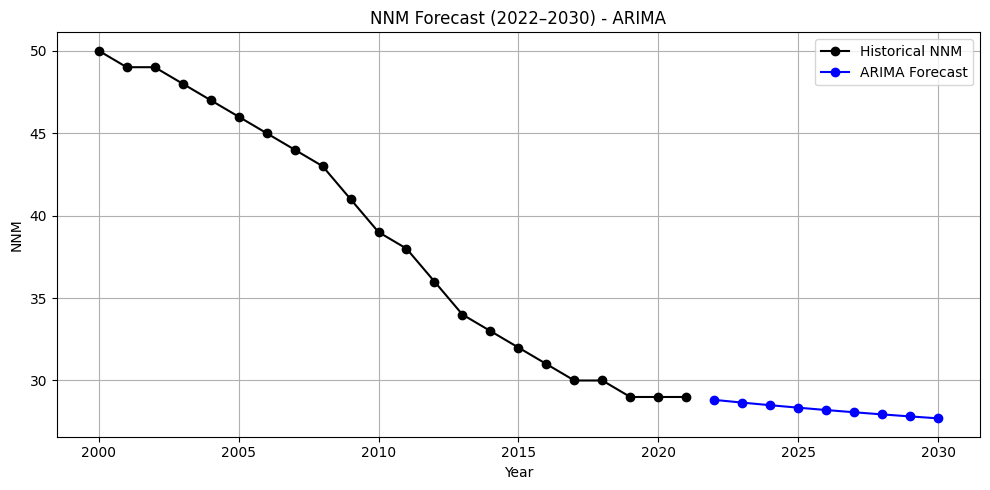

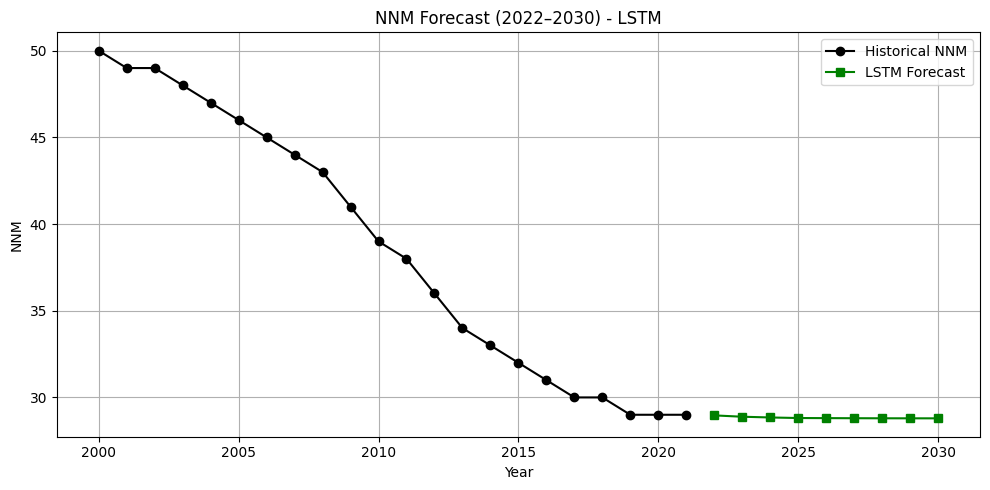

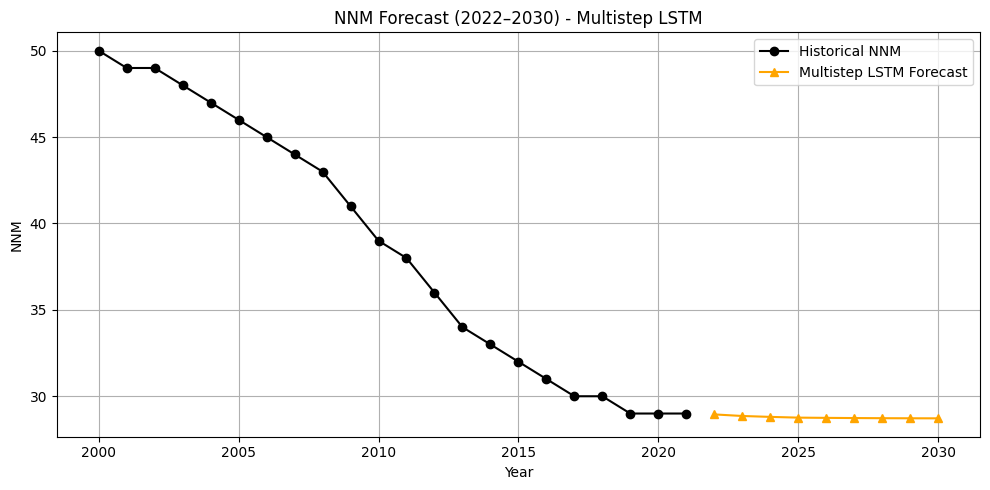

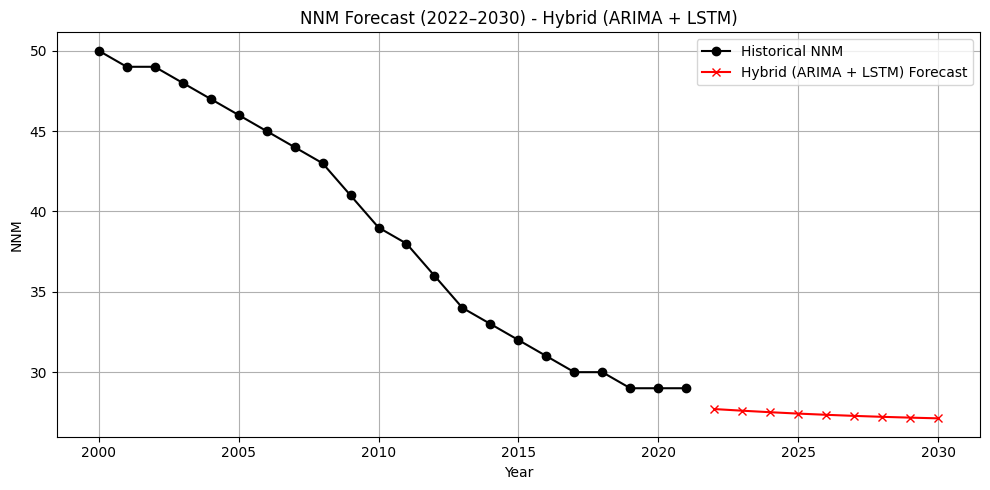

In [ ]:
# ---------- Separate Plots for Each Forecast Model ----------

# Create a base plot function
def plot_forecast(model_name, predictions, color, marker):
    plt.figure(figsize=(10, 5))
    plt.plot(df_series.index.year, df_series.values, label='Historical NNM', color='black', marker='o')
    plt.plot(future_years, predictions, label=f'{model_name} Forecast', color=color, marker=marker)
    plt.xlabel('Year')
    plt.ylabel('NNM')
    plt.title(f'NNM Forecast (2022–2030) - {model_name}')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot each model separately
plot_forecast('ARIMA', arima_pred, color='blue', marker='o')
plot_forecast('LSTM', lstm_pred, color='green', marker='s')
plot_forecast('Multistep LSTM', multi_lstm_pred, color='orange', marker='^')
plot_forecast('Hybrid (ARIMA + LSTM)', hybrid_pred, color='red', marker='x')


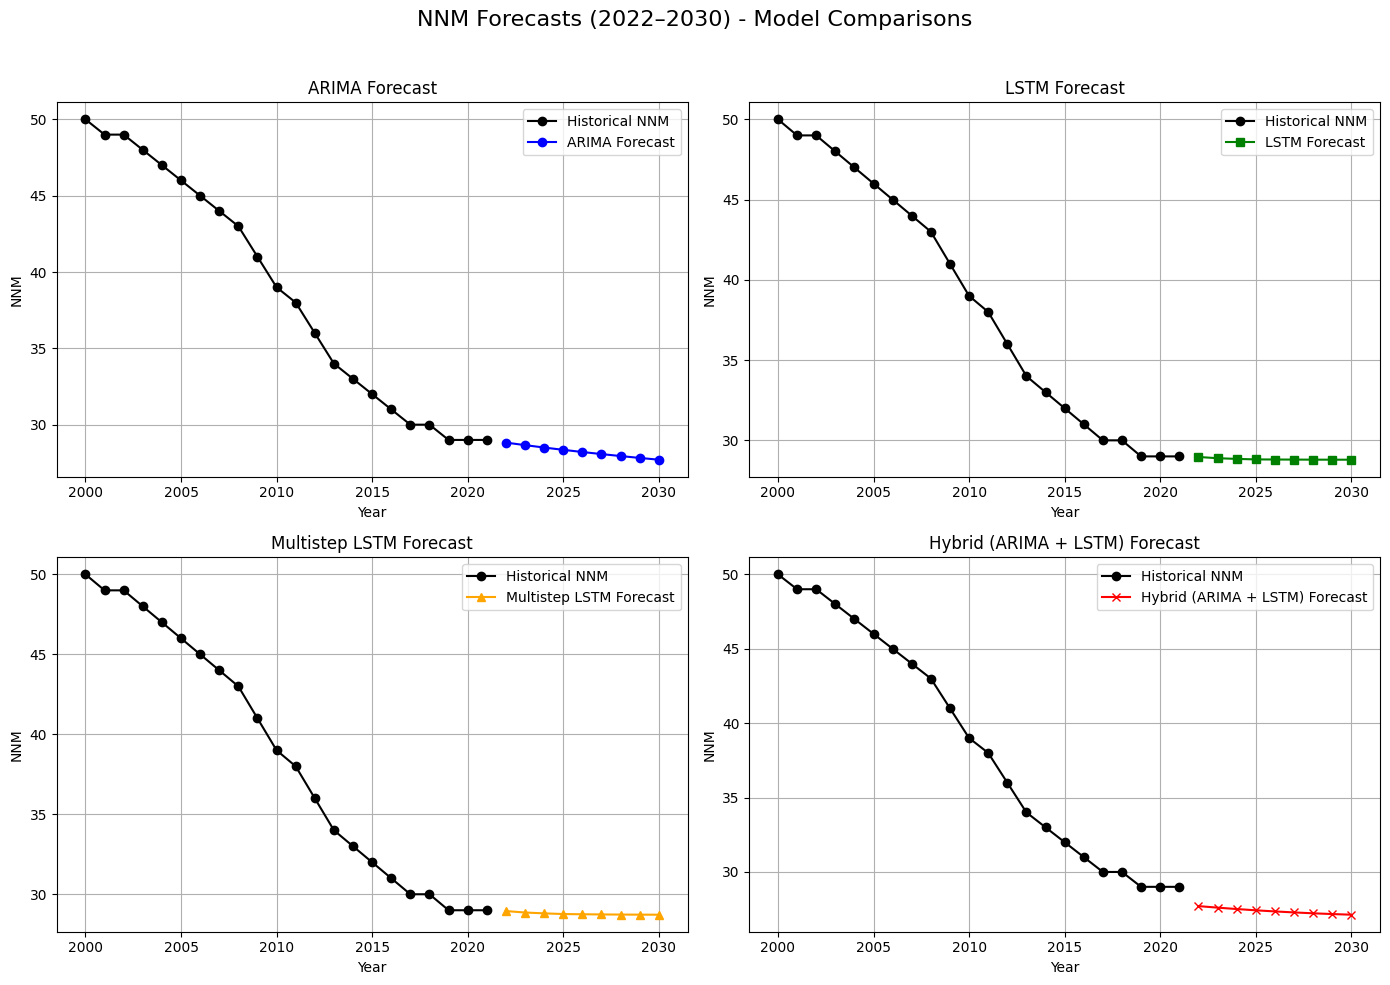

In [ ]:
# ---------- 2x2 Subplots for Forecast Models ----------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # To easily index as a flat list

# Define models and their settings
models = [
    ('ARIMA', arima_pred, 'blue', 'o'),
    ('LSTM', lstm_pred, 'green', 's'),
    ('Multistep LSTM', multi_lstm_pred, 'orange', '^'),
    ('Hybrid (ARIMA + LSTM)', hybrid_pred, 'red', 'x')
]

# Plot each in a subplot
for i, (name, pred, color, marker) in enumerate(models):
    ax = axes[i]
    ax.plot(df_series.index.year, df_series.values, label='Historical NNM', color='black', marker='o')
    ax.plot(future_years, pred, label=f'{name} Forecast', color=color, marker=marker)
    ax.set_title(f'{name} Forecast')
    ax.set_xlabel('Year')
    ax.set_ylabel('NNM')
    ax.grid(True)
    ax.legend()

# Adjust layout and show
plt.suptitle('NNM Forecasts (2022–2030) - Model Comparisons', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Ensure 'Year' is datetime and set it as the index
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

# Use the target variable
y = df['NNM']  # Now it's a time series with datetime index

# Fit ARIMA model (example: order=(1,1,1); you should tune this)
model_arima = ARIMA(y, order=(1, 1, 1))
model_arima_fit = model_arima.fit()

# Forecast from 2022 to 2030 (9 years ahead)
forecast_arima = model_arima_fit.forecast(steps=9)

# Assign proper datetime index for forecast
forecast_arima.index = pd.date_range(start='2022', periods=9, freq='Y')

# Plot observed and forecasted values
plt.figure(figsize=(10, 6))
y.plot(label='Observed data', marker='o')
forecast_arima.plot(label='ARIMA Forecast', linestyle='--', marker='x')
plt.legend()
plt.title("ARIMA Forecast of NNM (2022–2030)")
plt.xlabel("Year")
plt.ylabel("Neonatal Mortality Rate (NNM)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Extract year and target arrays
years = df['Year'].values  # e.g., [1990, 1991, ..., 2021]
y = df['NNM'].values.reshape(-1, 1)  # target as 2D array

# 2. Create multistep sequences (no scaling)
def create_multistep_sequences(data, input_steps, output_steps):
    X, y_seq = [], []
    for i in range(len(data) - input_steps - output_steps + 1):
        X.append(data[i:i + input_steps, 0])
        y_seq.append(data[i + input_steps:i + input_steps + output_steps, 0])
    return np.array(X), np.array(y_seq)

input_steps = 5
output_steps = 9
X_seq, y_seq = create_multistep_sequences(y, input_steps, output_steps)

# reshape for LSTM: (samples, time_steps, features)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

# 3. Build and train multistep LSTM model
model_seq = Sequential([
    LSTM(50, activation='relu', input_shape=(input_steps, 1)),
    Dense(output_steps)
])
model_seq.compile(optimizer='adam', loss='mse')
model_seq.fit(X_seq, y_seq, epochs=200, verbose=0)

# 4. Forecast next 9 years using last input window
last_input = y[-input_steps:].reshape(1, input_steps, 1)
forecast_seq = model_seq.predict(last_input).reshape(-1, 1)

# 5. Prepare forecast years (continuing after last year)
last_year = years[-1]
forecast_years = np.arange(last_year + 1, last_year + 1 + output_steps)

# 6. Plot observed + forecast
plt.figure(figsize=(10, 6))
plt.plot(years, y, label='Observed', marker='o')
plt.plot(forecast_years, forecast_seq, label='Multistep LSTM Forecast', linestyle='--', marker='x')

plt.title("Multistep LSTM Forecast of Neonatal Mortality Rate (2022–2030)")
plt.xlabel("Year")
plt.ylabel("Neonatal Mortality Rate")
plt.grid(True)
plt.legend()
plt.xticks(ticks=np.arange(years.min(), forecast_years[-1] + 1, 5))
plt.tight_layout()
plt.show()


In [ ]:
y.shape

In [ ]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(y)
print(f'p-value: {adf_test[1]}')

# Method #3: ADF test

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume y_train is a 1D NumPy array
y_diff = np.diff(y)

# Plot
plt.plot(y[1:], y_diff)  # Optionally use corresponding years if needed
plt.title("Differenced NNM (y_diff)")
plt.xlabel("Year")
plt.ylabel("Change in NNM")
plt.grid(True)
plt.show()


In [ ]:
acf_diff = plot_acf(y_train_diff)

pacf_diff = plot_pacf(y_train_diff)


In [ ]:
adf_test = adfuller(y_train_diff)
print(f'p-value: {adf_test[1]}')

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_original = plot_acf(y_train)

pacf_original = plot_pacf(y_train)

In [ ]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(y_train)
print(f'p-value: {adf_test[1]}')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure y_train is a Pandas Series
y_train_series = pd.Series(y_train)

# Apply differencing
df_train_diff = y_train_series.diff().dropna()

# Plot the differenced series
df_train_diff.plot()
plt.title("Differenced Training Series")
plt.show()


In [ ]:
acf_diff = plot_acf(df_train_diff)

pacf_diff = plot_pacf(df_train_diff)

In [ ]:
adf_test = adfuller(df_train_diff)
print(f'p-value: {adf_test[1]}')

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(y_train, order=(2,1,0))
model_fit = model.fit()
print(model_fit.summary())

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert residuals to Pandas Series
residuals = pd.Series(model_fit.resid[1:])

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot residuals
residuals.plot(title='Residuals', ax=ax[0])

# Plot density of residuals
residuals.plot(kind='kde', title='Density', ax=ax[1])

# Show plots
plt.tight_layout()
plt.show()


In [ ]:
acf_res = plot_acf(residuals)

pacf_res = plot_pacf(residuals)

In [ ]:
forecast_test = model_fit.forecast(len(y_test))

# Add forecast to the DataFrame
df['forecast_manual'] = [None]*len(y_train) + list(forecast_test)

# Plot with Year as index and NNM vs forecast
df[['NNM', 'forecast_manual']].plot(figsize=(10, 5), title='NNM and Forecast')
plt.xlabel('Year')
plt.ylabel('NNM')
plt.grid(True)
plt.show()
